# Segmentation RFM pour le projet GlobalShop Direct

## Préparation 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df_raw = pd.read_excel("../data/raw/Online_Retail.xlsx")

In [3]:
df_raw.to_csv("../data/raw/online_retail.csv", index=False)

In [4]:
print(df_raw.columns.tolist())
df_raw.head()

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df_raw.shape

(541909, 8)

Le dataset comprend 541 909 lignes et 8 colonnes.

In [6]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


- InvoiceDate est déjà au format date (datetime64).

- 4 colonnes sont de type texte (object), 2 sont de type décimal (float64) et 1 est de type entier (int64).

In [7]:
df_raw.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Deux colonnes ont des valeurs manquantes :
- CustomerID : 135 080 valeurs manquantes.
- Description : 1 454 valeurs manquantes. 

In [8]:
df_raw.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


- **Période couverte** : du 01/12/2010 au 09/12/2011.
- **Quantity** : le minimum est de **-80 995**. 
- **UnitPrice** : le minimum est de **-11 062,06**.
- La moyenne est bien plus élevée que la médiane (Quantity : 9,55 contre 3 ; UnitPrice : 4,61 contre 2,08), à cause de quelques valeurs très grandes.

## 1) Nettoyage 

### 1.1 Suppression des lignes 

In [9]:
df_clean = df_raw.copy()

Lignes_avant = df_clean.shape[0]
df_clean = df_clean.dropna(subset=["CustomerID"])
Lignes_apres = df_clean.shape[0]

print("Lignes avant :", Lignes_avant)
print("Lignes aprés :", Lignes_apres)
print("Lignes supprimées:", Lignes_avant - Lignes_apres)

Lignes avant : 541909
Lignes aprés : 406829
Lignes supprimées: 135080


### 1.2 créer une colonne pour les factures annulées (C)

In [10]:
df_clean["Annulation"] = df_clean["InvoiceNo"].astype(str).str.startswith("C")

print("Lignes d'annulation :", df_clean["Annulation"].sum())
print("Lignes d'achat :", (~df_clean["Annulation"]).sum())

Lignes d'annulation : 8905
Lignes d'achat : 397924


### 1.3 Garder que Quantités et prix positifs (hors annulations)

In [11]:
Lignes_avant = df_clean.shape[0]

df_clean = df_clean[df_clean["UnitPrice"] > 0]
df_clean = df_clean[(df_clean["Quantity"] > 0) | df_clean["Annulation"]]
Lignes_apres = df_clean.shape[0]

print("Lignes avant :", Lignes_avant)
print("Lignes après :", Lignes_apres)
print("Lignes supprimées :", Lignes_avant - Lignes_apres)

Lignes avant : 406829
Lignes après : 406789
Lignes supprimées : 40


### 1.4 Suppression des doublons

In [12]:
Lignes_avant = df_clean.shape[0]
print(" Doublons trouvés :", df_clean.duplicated().sum())

df_clean = df_clean.drop_duplicates()
Lignes_apres = df_clean.shape[0]

print("Lignes avant:", Lignes_avant)
print("Lignes après:", Lignes_apres)
print("Lignes supprimées:", Lignes_avant - Lignes_apres)

 Doublons trouvés : 5225
Lignes avant: 406789
Lignes après: 401564
Lignes supprimées: 5225


### 1.5 Conversion des types (InvoiceDate, CustomerID)

In [13]:
# On vérifie que chaque colonne a le type adapté à son usage : une date pour calculer la récence, un entier pour l'identifiant client
print("Avant :")
print(df_clean[["InvoiceDate", "CustomerID"]].dtypes)

df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])
df_clean["CustomerID"] = df_clean["CustomerID"].astype(int)

print("Après:")
print(df_clean[["InvoiceDate", "CustomerID"]].dtypes)

Avant :
InvoiceDate    datetime64[ns]
CustomerID            float64
dtype: object
Après:
InvoiceDate    datetime64[ns]
CustomerID              int64
dtype: object


- InvoiceDate était déjà au format date (datetime64) : la conversion sert de sécurité, sans rien changer.
- CustomerID passe de décimal (float64) à entier (int64). L'identifiant était stocké en décimal à cause des valeurs manquantes. Une fois celles-ci supprimées, on le repasse en entier pour qu'il reste un identifiant propre, notamment dans les fichiers exportés vers Looker Studio.

### 1.6 Création de la colonne TotalPrice
le fichier ne contient pas le montant de chaque ligne. Il donne seulement la quantité et le prix unitaire.

In [14]:
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]

print("Montant total des achats :", round(df_clean.loc[~df_clean["Annulation"], "TotalPrice"].sum(), 2))
print("Montant total des annulations :", round(df_clean.loc[df_clean["Annulation"], "TotalPrice"].sum(), 2))
print("Montant net :", round(df_clean["TotalPrice"].sum(), 2))

df_clean[["Quantity", "UnitPrice", "TotalPrice", "Annulation"]].head()

Montant total des achats : 8887208.89
Montant total des annulations : -608689.47
Montant net : 8278519.42


,Quantity,UnitPrice,TotalPrice,Annulation
0,6,2.55,15.30,False
1,6,3.39,20.34,False
2,8,2.75,22.00,False
3,6,3.39,20.34,False
4,6,3.39,20.34,False


In [15]:
round(-df_clean.loc[df_clean["Annulation"], "TotalPrice"].sum() / df_clean.loc[~df_clean["Annulation"], "TotalPrice"].sum() * 100, 1)
print("Part des annulations :", round(-df_clean.loc[df_clean["Annulation"], "TotalPrice"].sum() / df_clean.loc[~df_clean["Annulation"], "TotalPrice"].sum() * 100, 1), "%")

Part des annulations : 6.8 %


### 1.7 Bilan du nettoyage et sauvegarde

In [16]:
print("Lignes au départ :", df_raw.shape[0])
print("Lignes après nettoyage :", df_clean.shape[0])
print("Lignes supprimées au total :", df_raw.shape[0] - df_clean.shape[0])
print("Nombre de clients :", df_clean["CustomerID"].nunique())
print("Période : du", df_clean["InvoiceDate"].min(), "au", df_clean["InvoiceDate"].max())

df_clean.to_csv("../data/processed/online_retail_clean.csv", index=False)

Lignes au départ : 541909
Lignes après nettoyage : 401564
Lignes supprimées au total : 140345
Nombre de clients : 4371
Période : du 2010-12-01 08:26:00 au 2011-12-09 12:50:00


**Bilan du nettoyage :**
- On passe de **541 909** à **401 564 lignes**.
- Il reste **4 371 clients** différents.
- Période couverte : du 01/12/2010 au 09/12/2011.

Les données nettoyées sont enregistrées dans `data/processed/online_retail_clean.csv`.

## 2) Construction du dataset RFM

### 2.1 Date de référence

In [17]:
achats = df_clean[~df_clean["Annulation"]] # achats contient uniquement les achats, sans les annulations.

date_reference = achats["InvoiceDate"].max() + pd.Timedelta(days=1)
print("Date de référence :", date_reference)

Date de référence : 2011-12-10 12:50:00


**Date de référence :**

- Pour le RFM, on garde uniquement les achats (les annulations sont exclues).
- La date de référence est le lendemain du dernier achat : **10/12/2011 à 12h50**.
- Elle sert à calculer la Recency : le nombre de jours entre le dernier achat d'un client et cette date.


### 2.2 Calcul RFM

In [18]:
rfm = achats.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (date_reference - x.max()).days),
    Frequency=("InvoiceNo", "nunique")
)

rfm["Monetary"] = df_clean.groupby("CustomerID")["TotalPrice"].sum().round(2)

print("Clients avant filtre :", rfm.shape[0])
print("Clients avec Monetary <= 0 :", (rfm["Monetary"] <= 0).sum())

rfm = rfm[rfm["Monetary"] > 0]

print("Clients après filtre :", rfm.shape[0])
rfm.head()

Clients avant filtre : 4338
Clients avec Monetary <= 0 : 21
Clients après filtre : 4317


,Recency,Frequency,Monetary
CustomerID,,,
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40
12352,36,8,1545.41


**Calcul RFM :**

- **Recency** : nombre de jours entre le dernier achat du client et la date de référence.
- **Frequency** : nombre de factures différentes (commandes) du client.
- **Monetary** : montant net dépensé en £ (livre sterling), achats moins annulations.

Résultats :

- **4 338 clients** ont au moins un achat.
- **16 clients** ont un montant net nul ou négatif : ils sont retirés.
- Il reste **4 322 clients** dans le dataset RFM.

In [19]:
print("Clients sans aucun achat :", df_clean["CustomerID"].nunique() - achats["CustomerID"].nunique())

Clients sans aucun achat : 33


- Le nettoyage comptait 4 371 clients : **33 clients** n'ont que des annulations (aucun achat), ils n'apparaissent donc pas dans le RFM.

### 2.3 Statistiques descriptives et distributions

       Recency  Frequency   Monetary
count  4317.00    4317.00    4317.00
mean     92.25       4.29    1920.72
std      99.84       7.71    8267.02
min       1.00       1.00       2.90
25%      18.00       1.00     301.03
50%      51.00       2.00     653.75
75%     141.00       5.00    1624.21
max     374.00     209.00  279489.02


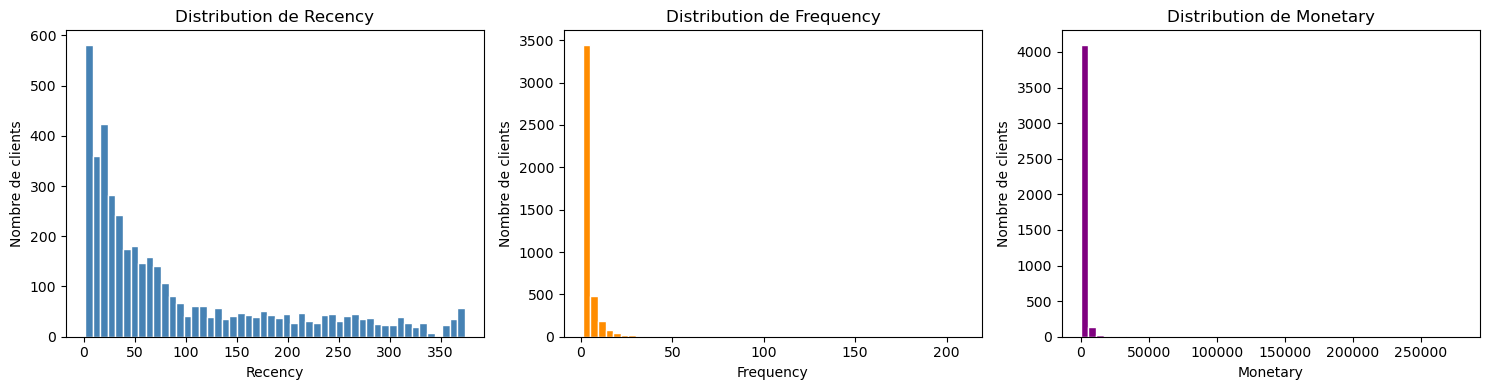

In [20]:
PALETTE = ["steelblue", "darkorange", "purple", "gold", "black", "grey"]

print(rfm.describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(["Recency", "Frequency", "Monetary"]):
    axes[i].hist(rfm[col], bins=50, color=PALETTE[i], edgecolor="white")
    axes[i].set_title("Distribution de " + col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Nombre de clients")

plt.tight_layout()
plt.show()

**Ce que montrent les statistiques**

Après nettoyage, il nous reste 4 317 clients.

Côté **Recency**, la moitié des clients a acheté pour la dernière fois il y a 51 jours ou moins. Mais l'écart est grand : certains sont revenus la veille (1 jour), d'autres n'ont rien acheté depuis 374 jours.

Côté **Frequency**, la plupart des clients commandent peu : la moitié a passé 2 commandes ou moins, et les trois quarts 5 commandes ou moins. À l'opposé, un client a passé 209 commandes.

Côté **Monetary**, on retrouve la même chose : la moitié des clients a dépensé 653,75 £ ou moins. Le plus gros client, lui, a dépensé 279 489,02 £.

Pour les trois variables, la moyenne est plus élevée que la médiane (par exemple 1 920,72  contre 653,75  pour Monetary). Quelques clients aux valeurs très élevées tirent la moyenne vers le haut. Les histogrammes le montrent bien : la grande majorité des clients est regroupée à gauche, avec une longue traîne de quelques clients exceptionnels.

Ces distributions semblent donc asymétriques. 

### 2.4 Sauvegarde de rfm.csv

In [21]:
rfm.to_csv("../data/processed/rfm.csv")

print("Fichier enregistré :", rfm.shape[0], "clients,", rfm.shape[1], "colonnes")

Fichier enregistré : 4317 clients, 3 colonnes


## 3) Prétraitement

### 3.1 Mesure de l'asymétrie

In [23]:
FEATURES = ["Recency", "Frequency", "Monetary"]

print("Asymétrie (skewness) :")
print(rfm[FEATURES].skew().round(2))

Asymétrie (skewness) :
Recency       1.25
Frequency    12.05
Monetary     21.59
dtype: float64


Chaque variable a une longue traîne vers la droite. Beaucoup de clients ont de petites valeurs, et quelques-uns ont des valeurs très élevées.

- **Recency : 1,25.** L'asymétrie est réelle, mais c'est la plus modérée des trois.
- **Frequency : 12,05.** Elle est très forte.
- **Monetary : 21,59.** C'est la plus forte des trois

Les trois valeurs dépassent 1, le seuil souvent utilisé pour parler de forte asymétrie. Si on laissait les données telles quelles, quelques clients extrêmes pèseraient trop dans le calcul des distances de K-means. 

### 3.2 Transformation log1p

Asymétrie après log1p :
Recency     -0.38
Frequency    1.20
Monetary     0.38
dtype: float64


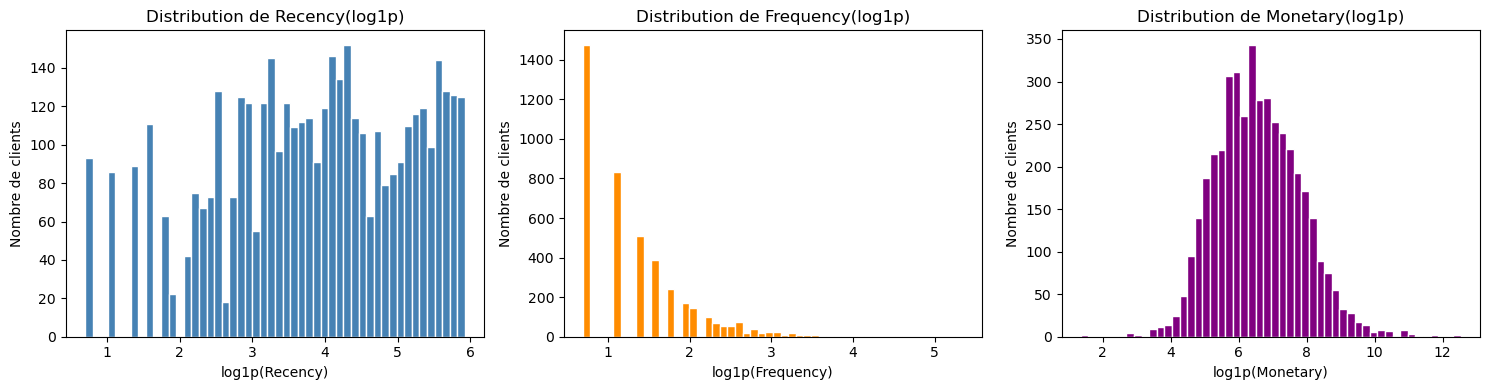

In [25]:
rfm_log = np.log1p(rfm[FEATURES])

print("Asymétrie après log1p :")
print(rfm_log.skew().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(FEATURES):
    axes[i].hist(rfm_log[col], bins=50, color=PALETTE[i], edgecolor="white")
    axes[i].set_title("Distribution de " + col + "(log1p)")
    axes[i].set_xlabel("log1p(" + col + ")")
    axes[i].set_ylabel("Nombre de clients")

plt.tight_layout()
plt.show()

- **Monetary** est la variable qui gagne le plus : son asymétrie passe de 21,59 à 0,38. L'histogramme a maintenant une forme proche d'une cloche.
- **Recency** passe de 1,25 à -0,38. Le signe négatif indique simplement une légère traîne vers la gauche, mais l'asymétrie reste faible.
- **Frequency** passe de 12,05 à 1,20. C'est une très forte baisse.

### 3.3 Standardisation

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = pd.DataFrame(
    scaler.fit_transform(rfm_log),
    columns=FEATURES,
    index=rfm_log.index
)

print(rfm_scaled.describe().round(2))

       Recency  Frequency  Monetary
count  4317.00    4317.00   4317.00
mean     -0.00      -0.00     -0.00
std       1.00       1.00      1.00
min      -2.34      -0.96     -4.18
25%      -0.66      -0.96     -0.69
50%       0.09      -0.37     -0.07
75%       0.84       0.65      0.66
max       1.57       5.85      4.80


Après le log, les trois variables n'étaient toujours pas sur la même échelle. On les standardise avec `StandardScaler` : pour chaque valeur, on retire la moyenne de la colonne puis on divise par son écart-type.

Le `describe()` le confirme : les trois variables ont maintenant une **moyenne de 0** et un **écart-type de 1**. 

Les trois variables ont maintenant le même poids : K-means pourra comparer les clients sans qu'une variable domine les autres.

### 3.4 Sauvegarde du scaler

On sauvegarde le scaler et le modèle pour que l'application applique exactement les mêmes transformations et la même segmentation aux nouveaux clients, sans réentraîner le modèle.

In [28]:
import joblib

joblib.dump(scaler,"../models/scaler.joblib")

scaler_charge = joblib.load("../models/scaler.joblib")
print("Scaler rechargé identique :", np.allclose(scaler_charge.transform(rfm_log), rfm_scaled))

Scaler rechargé identique : True
